In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [51]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [52]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

Their is no null values in dataset

In [53]:
df[df.duplicated()]
df.duplicated().sum()

np.int64(0)

Their is no Duplicate Values Found in dataset

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [55]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [56]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [57]:
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']
for feature in categorical_feature:
    print(f'Total unique values in {feature} column : {df[feature].unique()} \n',end='')

Total unique values in gender column : ['female' 'male'] 
Total unique values in race_ethnicity column : ['group B' 'group C' 'group A' 'group D' 'group E'] 
Total unique values in parental_level_of_education column : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school'] 
Total unique values in lunch column : ['standard' 'free/reduced'] 
Total unique values in test_preparation_course column : ['none' 'completed'] 


In [58]:
numerical_feature = [feature for feature in df.columns if df[feature].dtype != 'O']
numerical_feature

['math_score', 'reading_score', 'writing_score']

In [59]:
for feature in categorical_feature:
    print('{} : Total unique values are : {} and values are {} \n'.format(feature, df[feature].nunique(),df[feature].unique()))

gender : Total unique values are : 2 and values are ['female' 'male'] 

race_ethnicity : Total unique values are : 5 and values are ['group B' 'group C' 'group A' 'group D' 'group E'] 

parental_level_of_education : Total unique values are : 6 and values are ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school'] 

lunch : Total unique values are : 2 and values are ['standard' 'free/reduced'] 

test_preparation_course : Total unique values are : 2 and values are ['none' 'completed'] 



In [60]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [61]:
df['total_score'] = df['writing_score'] + df['reading_score'] + df['math_score']
df['total_score']

0      218
1      247
2      278
3      148
4      229
      ... 
995    282
996    172
997    195
998    223
999    249
Name: total_score, Length: 1000, dtype: int64

In [62]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [63]:
##let us first afhal add the average score as separate column
df['average'] = (df['math_score'] + df['reading_score'] + df['writing_score'])/3 
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [64]:
math_score_full = df[df['math_score'] == 100]['average'].count()
reading_score_full = df[df['reading_score'] == 100]['average'].count()
writing_score_full = df[df['writing_score'] == 100]['average'].count()
print(math_score_full)
print(reading_score_full)
print(writing_score_full)


7
17
14


In [65]:
math_score_lessthan_20 = df[df['math_score'] <= 20]['average'].count()
reading_score_lessthan_20 = df[df['reading_score'] <= 20]['average'].count()
writing_score_lessthan_20 = df[df['writing_score'] <= 20]['average'].count()
print(math_score_lessthan_20)
print(reading_score_lessthan_20)
print(writing_score_lessthan_20)


4
1
3


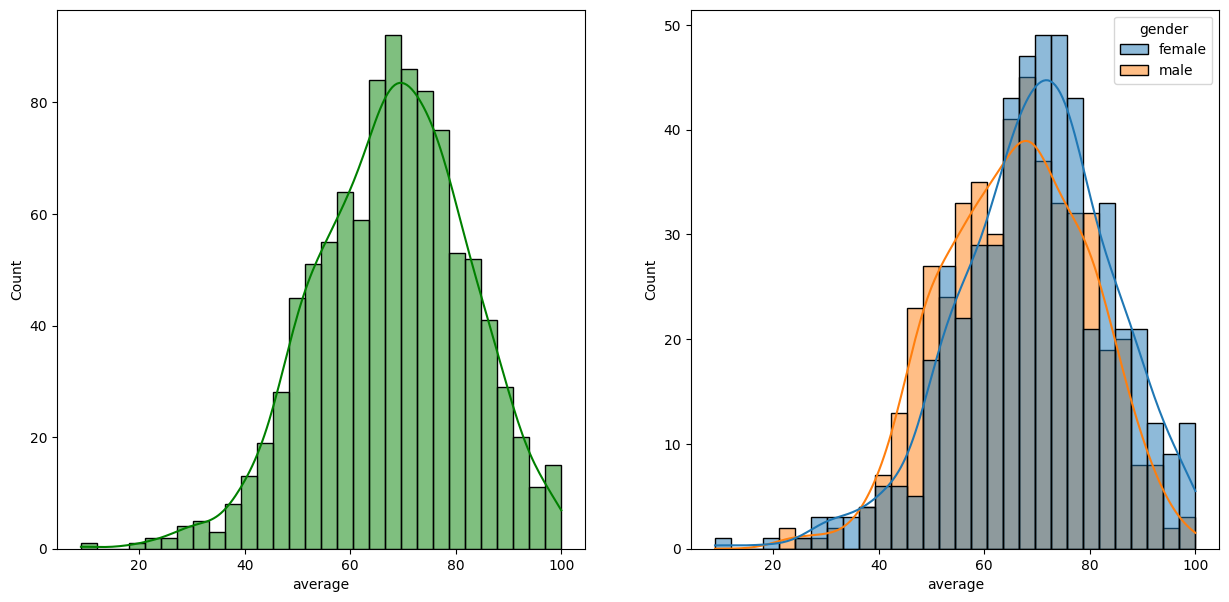

In [68]:
fig , axis = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(df,x='average',bins=30,kde=True,hue='gender')
plt.show()
